# 05 · Two checks that need more slides

**Why this notebook exists.** Notebook 01 chose the 30 smallest files per
class because small files download fast. That is a selection bias, listed as
limitation 3 in the technical report. It also used only two subtypes. This
notebook downloads more overviews from the open GDC portal and asks two
questions.

| § | Question | What is downloaded |
|---|---|---|
| 2 | Does the result survive a random choice of patients instead of the smallest files | 30 + 30 randomly chosen LMS and DDLPS patients |
| 3 | Does the pipeline still separate subtypes when a third, harder class is added | 30 undifferentiated pleomorphic sarcoma (UPS) patients |

Everything is cached under `data/`, so a rerun only downloads what is
missing. Numbers are written into the text after the run.

## 1 · Setup

**Story.** Same pipeline as notebook 01, copied here so the notebook stands
alone: tile at 224 px, keep tiles with at least 40 per cent tissue, frozen
ImageNet ResNet50, mean over tiles, standardise, logistic regression.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import fetch_overviews as fo

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
HERE = Path.cwd(); DATA = HERE / "data"; FIG = HERE / "figures"
OVERVIEWS = DATA / "overviews"
FEAT_DIR = DATA / "features_by_case"; FEAT_DIR.mkdir(exist_ok=True)

TILE, MIN_TISSUE = 224, 0.40
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone = torchvision.models.resnet50(weights=weights)
backbone.fc = torch.nn.Identity(); backbone = backbone.eval()
preprocess = weights.transforms()


def tile_overview(png_path):
    img = np.asarray(Image.open(png_path).convert("RGB"))
    h, w, _ = img.shape; grey = img.mean(axis=2); tiles = []
    for y in range(0, h - TILE + 1, TILE):
        for x in range(0, w - TILE + 1, TILE):
            if (grey[y:y + TILE, x:x + TILE] < 220).mean() >= MIN_TISSUE:
                tiles.append(img[y:y + TILE, x:x + TILE])
    return tiles


@torch.no_grad()
def slide_feature(png_path, batch=32):
    # 一張 overview → 2048 維，結果以病人為名快取
    cache = FEAT_DIR / (Path(png_path).stem + ".npy")
    if cache.exists():
        return np.load(cache)
    tiles = tile_overview(png_path)
    if len(tiles) < 3:
        return None
    feats = []
    for s in range(0, len(tiles), batch):
        feats.append(backbone(torch.stack([preprocess(Image.fromarray(t)) for t in tiles[s:s + batch]])))
    vec = torch.cat(feats).mean(dim=0).numpy()
    np.save(cache, vec)
    return vec


def make_model(multi=False):
    return make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=4000, random_state=SEED))


def features_for(cohort):
    X, keep = [], []
    for row in tqdm(cohort.itertuples(), total=len(cohort), desc="features"):
        vec = slide_feature(row.png)
        if vec is not None:
            X.append(vec); keep.append(row.Index)
    return np.stack(X), cohort.loc[keep].reset_index(drop=True)


def oof_binary(X, y, seed=SEED):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    out = np.zeros(len(y))
    for tr, te in cv.split(X, y):
        out[te] = make_model().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return out


def bootstrap_ci(y, p, n=2000):
    rng = np.random.default_rng(SEED); vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() != y[idx].max():
            vals.append(roc_auc_score(y[idx], p[idx]))
    return np.percentile(vals, [2.5, 97.5])


slides = pd.read_csv(DATA / "tcga_sarc_slides_all.csv")
print("slides listed:", len(slides), "patients:", slides["case"].nunique())

slides listed: 600 patients: 254


**Output.** The slide list cached by notebook 01 and the model ready on CPU.

## 2 · Random patients instead of the smallest files

**Story.** Draw 30 LMS and 30 DDLPS patients at random (seed 42) from all
patients with a diagnostic slide, one slide per patient chosen at random too,
download the overviews that are not already cached, and run the identical
5-fold cross-validation. If the AUC and its interval overlap the smallest-file
result, the selection bias did not make the result.

In [2]:
CLASSES = {"Leiomyosarcoma, NOS": "LMS", "Dedifferentiated liposarcoma": "DDLPS"}
sub = slides[slides["diagnosis"].isin(CLASSES)].copy()
sub["label"] = sub["diagnosis"].map(CLASSES)
rng = np.random.default_rng(SEED)
one_per_case = sub.sample(frac=1, random_state=SEED).drop_duplicates("case")   # 每人隨機留一張
random_cohort = (one_per_case.groupby("label", group_keys=False)
                 .apply(lambda g: g.sample(n=30, random_state=SEED)).reset_index(drop=True))
print(random_cohort.groupby("label")["file_size_mb"].describe()[["count", "mean", "min", "max"]])

smallest = pd.read_csv(DATA / "cohort.csv")
print("overlap with the smallest-file cohort:", len(set(random_cohort["case"]) & set(smallest["case"])), "patients")
random_cohort = fo.fetch_cohort(random_cohort, OVERVIEWS)   # 已有的跳過
random_cohort.to_csv(DATA / "cohort_random.csv", index=False)

C:\Users\User\AppData\Local\Temp\ipykernel_65152\1682727678.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=30, random_state=SEED)).reset_index(drop=True))


       count         mean         min          max
label                                             
DDLPS   30.0  1558.513025  439.829376  2812.419481
LMS     30.0  1146.555996   71.611334  2776.299457
overlap with the smallest-file cohort: 36 patients


fetch overviews:   0%|          | 0/60 [00:00<?, ?it/s]

fetch overviews: 100%|██████████| 60/60 [00:00<00:00, 7440.45it/s]

**Output.** File sizes of the random cohort (compare with the smallest-file
cohort in notebook 01 §3), the overlap between the two cohorts, and the
download progress. Random files are larger, so their overviews take longer to
read.

features:   0%|          | 0/60 [00:00<?, ?it/s]

random cohort: n = 60, out-of-fold AUC 0.810, 95% CI 0.69 to 0.91


smallest-file cohort: n = 60, out-of-fold AUC 0.822, 95% CI 0.70 to 0.92


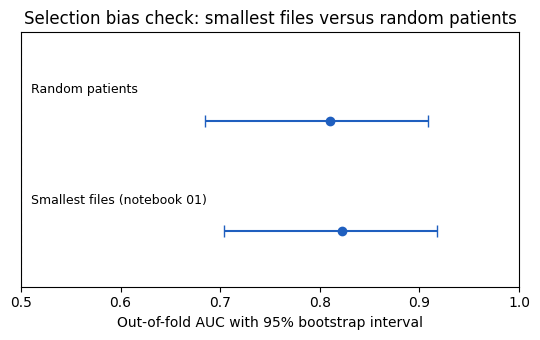

In [3]:
X_r, random_cohort = features_for(random_cohort)
y_r = (random_cohort["label"] == "DDLPS").astype(int).to_numpy()
oof_r = oof_binary(X_r, y_r)
auc_r = roc_auc_score(y_r, oof_r); ci_r = bootstrap_ci(y_r, oof_r)
print(f"random cohort: n = {len(y_r)}, out-of-fold AUC {auc_r:.3f}, 95% CI {ci_r[0]:.2f} to {ci_r[1]:.2f}")

# 跟最小檔 cohort 的結果並排
feats = np.load(DATA / "slide_features.npz", allow_pickle=True)
small = smallest.set_index("case").loc[list(feats["cases"])].reset_index()
y_s = (small["label"] == "DDLPS").astype(int).to_numpy()
oof_s = oof_binary(feats["X"], y_s)
auc_s = roc_auc_score(y_s, oof_s); ci_s = bootstrap_ci(y_s, oof_s)
print(f"smallest-file cohort: n = {len(y_s)}, out-of-fold AUC {auc_s:.3f}, 95% CI {ci_s[0]:.2f} to {ci_s[1]:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 3.5))
for i, (name, auc, ci) in enumerate([("Smallest files (notebook 01)", auc_s, ci_s), ("Random patients", auc_r, ci_r)]):
    ax.errorbar(auc, i, xerr=[[auc - ci[0]], [ci[1] - auc]], fmt="o", color="#1f5fbf", capsize=4)
    ax.text(0.51, i + 0.22, name, fontsize=9, va="bottom")
ax.set_yticks([]); ax.set_xlim(0.5, 1.0); ax.set_ylim(-0.5, 1.8); ax.axvline(0.5, color="#9aa7ba", ls="--")
ax.set_xlabel("Out-of-fold AUC with 95% bootstrap interval")
ax.set_title("Selection bias check: smallest files versus random patients")
plt.tight_layout(); plt.savefig(FIG / "fig10_random_vs_smallest.png", dpi=120); plt.show()

**Output.** Figure 10. Two point estimates with intervals. Overlapping
intervals mean the smallest-file shortcut did not manufacture the result;
a clearly lower random-cohort AUC would mean it did, and the report would
have to say so.

## 3 · A third class: undifferentiated pleomorphic sarcoma

**Story.** UPS is the hardest of the common subtypes, a diagnosis of
exclusion with no defining molecular event. Adding it as a third class makes
the task closer to the clinic and harder for a mean-pooled overview model.
Thirty smallest-file UPS patients are downloaded, the three-class logistic
regression is cross-validated, and each class gets a one-versus-rest AUC.

fetch overviews:   0%|          | 0/30 [00:00<?, ?it/s]

fetch overviews: 100%|██████████| 30/30 [00:00<00:00, 7442.43it/s]

features:   0%|          | 0/30 [00:00<?, ?it/s]

UPS patients with usable overviews: 30


LMS    one-vs-rest AUC 0.822
DDLPS  one-vs-rest AUC 0.832
UPS    one-vs-rest AUC 0.833
macro AUC 0.829, accuracy 0.67 (chance 0.33), n = 90


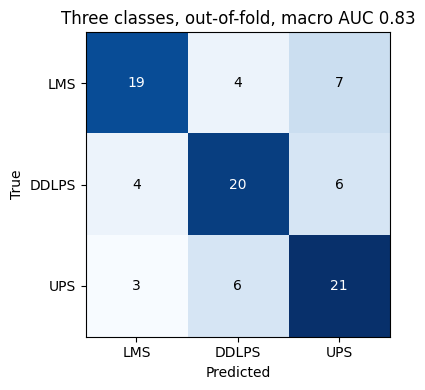

In [4]:
ups = slides[slides["diagnosis"] == "Undifferentiated sarcoma"].copy()
ups["label"] = "UPS"
ups = ups.sort_values("file_size_mb").drop_duplicates("case").head(30).reset_index(drop=True)
ups = fo.fetch_cohort(ups, OVERVIEWS)
X_u, ups = features_for(ups)
print("UPS patients with usable overviews:", len(ups))

X3 = np.vstack([feats["X"], X_u])
labels3 = np.array(list(small["label"]) + ["UPS"] * len(ups))
classes = ["LMS", "DDLPS", "UPS"]
y3 = np.array([classes.index(l) for l in labels3])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof3 = np.zeros((len(y3), 3))
for tr, te in cv.split(X3, y3):
    oof3[te] = make_model(multi=True).fit(X3[tr], y3[tr]).predict_proba(X3[te])
for k, name in enumerate(classes):
    print(f"{name:6s} one-vs-rest AUC {roc_auc_score(y3 == k, oof3[:, k]):.3f}")
macro = np.mean([roc_auc_score(y3 == k, oof3[:, k]) for k in range(3)])
acc = (oof3.argmax(1) == y3).mean()
print(f"macro AUC {macro:.3f}, accuracy {acc:.2f} (chance 0.33), n = {len(y3)}")

cm = confusion_matrix(y3, oof3.argmax(1))
fig, ax = plt.subplots(figsize=(4.2, 4))
ax.imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks(range(3)); ax.set_xticklabels(classes); ax.set_yticks(range(3)); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Three classes, out-of-fold, macro AUC {macro:.2f}")
plt.tight_layout(); plt.savefig(FIG / "fig11_three_class_confusion.png", dpi=120); plt.show()

**Output.** Figure 11 and three one-versus-rest AUCs. UPS is expected to be
the class most often confused, because it has no defining morphology at
overview resolution. Whatever the numbers, they go into the technical report
as they are.

## 4 · Summary

Written into the technical report, section 10, after the run.